# EDA — `complaints`: is there an opportunity for an agentic complaint workflow, and how do compensation and satisfaction relate to time-to-resolution?

**Business hypothesis.** An agentic workflow (triage, routing, first response, resolution support)
could solve complaints **better and faster**. Alongside, we want to **quantify `compensation_granted`
and `resolution_satisfaction`** and relate them to **time-to-resolution**.

**Questions.**

1. What is the complaint volume, backlog and speed today (the baseline an agentic workflow would improve)?
2. How much compensation is granted, and how is it decided (claim, category, priority, time)?
3. How satisfied are customers, and is satisfaction related to time-to-resolution or compensation?
4. Does the data support sizing the opportunity, and what is missing to do it properly?

Scope: all 1,097 daily files (2023-06-17 to 2026-06-17), descriptive analysis only, no model. Nothing is
imputed or invented. The dataset is small (~17 MB on disk), so it is loaded whole; process memory is measured.

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
COMPLAINTS_ROOT = REPO_ROOT / "data" / "complaints"
DATA_DIRECTORY = REPO_ROOT / "data" / "data"

DATE_COLUMNS = ["creation_date", "assignment_date", "first_response_date", "resolution_date", "closing_date"]
BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"
RESOLUTION_DAY_BINS = [0, 5, 10, 15, 20, 25, 30]


def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to show the analysis stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


memory_start_mb = current_memory_mb()
partition_files = sorted(COMPLAINTS_ROOT.glob("year=*/month=*/day=*/complaints_*.csv"))
complaints = pd.concat((pd.read_csv(path) for path in partition_files), ignore_index=True)
for column in DATE_COLUMNS:
    complaints[column] = pd.to_datetime(complaints[column])
AS_OF = complaints["creation_date"].max()

display(pd.Series({
    "daily files": len(partition_files),
    "complaints": len(complaints),
    "first / last creation_date": f"{complaints['creation_date'].min()} / {AS_OF}",
    "distinct customers": complaints["customer_id"].nunique(),
    "distinct agents": complaints["assigned_agent_id"].nunique(),
    "process memory before / after loading, MB": f"{memory_start_mb:,.0f} / {current_memory_mb():,.0f}",
}, name="value").to_frame())

,value
daily files,1097
complaints,67095
first / last creation_date,2023-06-17 08:07:05 / 2026-06-18 07:56:52
distinct customers,54145
distinct agents,1200
"process memory before / after loading, MB",129 / 233


`AS_OF` (the latest `creation_date`) is used as "today" for ages, since the file has no snapshot date.

## 2. Structure and data quality

In [2]:
schema = pd.DataFrame({
    "dtype": complaints.dtypes.astype(str),
    "missing_pct": complaints.isna().mean() * 100,
    "distinct": complaints.nunique(),
})
display(schema)
display(pd.Series({
    "duplicate complaint_id": complaints["complaint_id"].duplicated().sum(),
    "distinct `description` texts": complaints["description"].nunique(),
    "distinct `resolution` texts": complaints["resolution"].nunique(),
    "origin_interaction_id populated": complaints["origin_interaction_id"].notna().sum(),
}, name="value").to_frame())
display(complaints["resolution"].value_counts().to_frame("complaints"))

,dtype,missing_pct,distinct
complaint_id,str,0.00,67095
creation_date,datetime64[us],0.00,67074
process_date,str,0.00,1097
customer_id,str,0.00,54145
case_type,str,0.00,4
category,str,0.00,5
subcategory,str,9.98,5
reception_channel,str,0.00,6
affected_product_id,str,33.57,42184
related_branch_id,str,71.42,350


,value
duplicate complaint_id,0
distinct `description` texts,5
distinct `resolution` texts,5
origin_interaction_id populated,0


,complaints
resolution,
Se revisó el caso y se realizó el ajuste correspondiente en la cuenta del cliente.,3132
Se escaló a área correspondiente y se aplicó la solución definitiva.,3098
Se brindó explicación detallada al cliente y se resolvió la situación.,3078
Se otorgó compensación al cliente por las molestias ocasionadas.,3034
Se verificó la información y se procedió con la corrección solicitada.,2968


There is **no free text**: `description` is one sentence per category (`Queja relacionada con <category>`) and
`resolution` is one of five fixed sentences. `origin_interaction_id` (the link to the interaction that
originated the complaint) is empty everywhere. Consequence for an agentic workflow: this dataset can
describe *when and how fast* things happen, but it cannot be used to evaluate an agent's reading or
writing of complaint text.

### Lifecycle: what each status carries

In [3]:
LIFECYCLE_FIELDS = ["assigned_agent_id", "first_response_date", "resolution_date", "closing_date", "resolution",
                    "resolution_days", "compensation_granted", "resolution_satisfaction"]
display(complaints["status"].value_counts().to_frame("complaints").assign(share_pct=lambda t: t["complaints"] / t["complaints"].sum() * 100))
display(complaints.groupby("status")[LIFECYCLE_FIELDS].agg(lambda s: s.notna().mean() * 100))

,complaints,share_pct
status,,
In Process,26823,39.98
Open,20125,29.99
Resolved,13512,20.14
Escalated,3321,4.95
Closed,2609,3.89
Rejected,705,1.05


,assigned_agent_id,first_response_date,resolution_date,closing_date,resolution,resolution_days,compensation_granted,resolution_satisfaction
status,,,,,,,,
Closed,95.21,95.82,94.63,95.09,94.94,95.52,29.40,95.21
Escalated,94.61,0.00,0.00,0.00,0.00,0.00,0.00,0.00
In Process,95.06,95.04,0.00,0.00,0.00,0.00,0.00,0.00
Open,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Rejected,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Resolved,95.15,95.18,95.32,0.00,94.97,95.26,28.67,0.00


The lifecycle is coherent by status: `Open` and `Rejected` have no agent; `In Process` has an agent and a
first response; `Escalated` has an agent but **no first response**; `Resolved`/`Closed` have resolution
data. Two facts matter for the questions above: **`resolution_satisfaction` exists only on `Closed`
cases**, and `compensation_granted` only on `Resolved`/`Closed` ones. About 5% of rows inside each
lifecycle bucket miss a field.

### Timestamp and consistency checks

In [4]:
hours_to_assignment = (complaints["assignment_date"] - complaints["creation_date"]).dt.total_seconds() / 3600
hours_to_first_response = (complaints["first_response_date"] - complaints["creation_date"]).dt.total_seconds() / 3600
days_between_dates = (complaints["resolution_date"] - complaints["creation_date"]).dt.total_seconds() / 86400
business_day = (complaints["creation_date"] - pd.Timedelta(hours=8)).dt.normalize()

display(pd.Series({
    "assignment before creation": (complaints["assignment_date"] < complaints["creation_date"]).sum(),
    "first response before assignment": (complaints["first_response_date"] < complaints["assignment_date"]).sum(),
    "resolution before first response": (complaints["resolution_date"] < complaints["first_response_date"]).sum(),
    "closing before resolution": (complaints["closing_date"] < complaints["resolution_date"]).sum(),
    "resolution_days differs from (resolution_date - creation_date) where both exist":
        ((days_between_dates - complaints["resolution_days"]).abs() > 1e-6).sum(),
    "resolution_days present but resolution_date missing":
        (complaints["resolution_days"].notna() & complaints["resolution_date"].isna()).sum(),
    "assignment_date after AS_OF": (complaints["assignment_date"] > AS_OF).sum(),
    "first_response_date after AS_OF": (complaints["first_response_date"] > AS_OF).sum(),
    "resolution_date after AS_OF": (complaints["resolution_date"] > AS_OF).sum(),
    "closing_date after AS_OF": (complaints["closing_date"] > AS_OF).sum(),
    "process_date differs from (creation_date - 8 h).date": (business_day != pd.to_datetime(complaints["process_date"])).sum(),
}, name="count").to_frame())

display(pd.DataFrame({
    "hours to assignment": hours_to_assignment.describe(),
    "hours to first response": hours_to_first_response.describe(),
    "days to resolution": complaints["resolution_days"].describe(),
}))

,count
assignment before creation,0
first response before assignment,0
resolution before first response,492
closing before resolution,0
resolution_days differs from (resolution_date - creation_date) where both exist,0
resolution_days present but resolution_date missing,737
assignment_date after AS_OF,31
first_response_date after AS_OF,70
resolution_date after AS_OF,211
closing_date after AS_OF,46


,hours to assignment,hours to first response,days to resolution
count,"43,967.00","40,853.00","15,363.00"
mean,12.45,37.50,15.60
std,6.92,15.19,8.71
min,1.00,3.00,1.00
25%,6.00,26.00,8.00
50%,12.00,38.00,16.00
75%,18.00,49.00,23.00
max,24.00,72.00,30.00


Resolution days are internally consistent with the dates. `process_date` follows a business-day cut-over, at
**08:00 here** (complaints created 00:00-07:59 belong to the previous day; transactions cut over at 06:00), and
the rule holds for all but one row. 492 cases are resolved before their first response. Several timestamps fall **after `AS_OF`**, meaning events dated in the
future relative to the newest complaint. The stage durations are **uniform**: assignment 1-24 h, first
response 3-72 h, resolution 1-30 days, which is what random generation looks like (see section 4).

## 3. Volume and mix

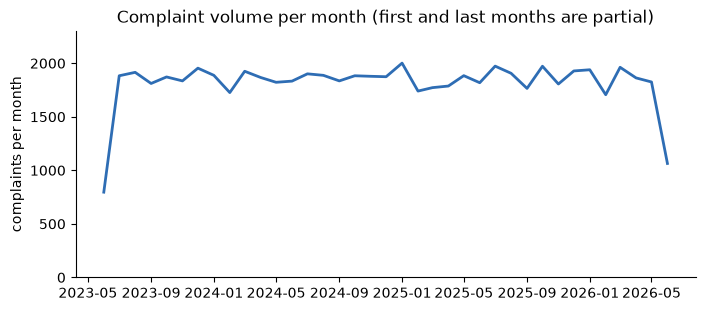

,complaints per full month
count,35.00
mean,"1,863.86"
std,72.67
min,"1,706.00"
25%,"1,820.00"
50%,"1,874.00"
75%,"1,910.50"
max,"2,001.00"


,case_type (%)
case_type,
Complaint,60.29
Claim,24.74
Request,10.08
Suggestion,4.89


,category (%)
category,
Transactions,20.24
Fees,20.20
Technical,19.98
Branch,19.91
Service,19.66


,subcategory (%)
subcategory,
Cargo no reconocido,18.33
Cobro indebido,18.17
Problema con app,18.08
Atención en sucursal,17.72
Calidad de servicio,17.72
NaN,9.98


,reception_channel (%)
reception_channel,
Call Center,50.32
Email,19.86
Web,14.73
App,10.03
Branch,4.00
Regulator,1.07


,priority (%)
priority,
Medium,49.84
Low,30.42
High,14.74
Critical,5.00


In [5]:
monthly = complaints.groupby(complaints["creation_date"].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(monthly.index.to_timestamp(), monthly.values, color=BAR_COLOR, linewidth=2)
ax.set_ylim(0, monthly.max() * 1.15)
ax.set_ylabel("complaints per month")
ax.set_title("Complaint volume per month (first and last months are partial)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(monthly.iloc[1:-1].describe().to_frame("complaints per full month"))
for column in ["case_type", "category", "subcategory", "reception_channel", "priority"]:
    display((complaints[column].value_counts(dropna=False, normalize=True) * 100).to_frame(f"{column} (%)"))

Volume is flat at about 1,870 complaints per full month (median 1,874; range 1,706-2,001; roughly 60 a day) with no trend. The mix is
uniform: five categories at ~20% each, five subcategories at ~18% each (10% missing), and priority
30% Low / 50% Medium / 15% High / 5% Critical. `Regulator` is only 1% of the volume.

## 4. Baseline for an agentic workflow: backlog and speed

`Rejected`, `Resolved` and `Closed` are terminal. The **active backlog** is `Open` + `In Process` + `Escalated`.

,value
complaints,"67,095.00"
active backlog (Open + In Process + Escalated),"50,269.00"
as % of all complaints,74.92
older than 90 days,"46,097.00"
older than 1 year,"33,413.00"
"Open, no agent assigned","20,125.00"
"Escalated, no first response","3,321.00"
complaints with no agent at all (any status),"23,115.00"


,complaints,terminal_pct,has_agent_pct
age_band,,,
<= 30 d,1904,25.42,66.23
31-90 d,3672,25.05,66.15
91-180 d,5552,25.92,66.43
181-365 d,11424,24.97,65.29
1-2 years,22272,25.06,65.64
> 2 years,22271,24.92,65.21


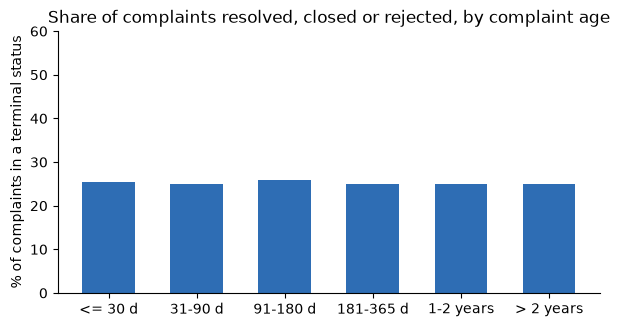

In [6]:
TERMINAL_STATUSES = ["Resolved", "Closed", "Rejected"]
complaints["is_terminal"] = complaints["status"].isin(TERMINAL_STATUSES)
complaints["age_days"] = (AS_OF - complaints["creation_date"]).dt.days
AGE_BINS = [-1, 30, 90, 180, 365, 730, 5000]
AGE_LABELS = ["<= 30 d", "31-90 d", "91-180 d", "181-365 d", "1-2 years", "> 2 years"]
complaints["age_band"] = pd.cut(complaints["age_days"], AGE_BINS, labels=AGE_LABELS)

backlog = complaints[~complaints["is_terminal"]]
display(pd.Series({
    "complaints": len(complaints),
    "active backlog (Open + In Process + Escalated)": len(backlog),
    "  as % of all complaints": len(backlog) / len(complaints) * 100,
    "  older than 90 days": (backlog["age_days"] > 90).sum(),
    "  older than 1 year": (backlog["age_days"] > 365).sum(),
    "  Open, no agent assigned": (backlog["status"] == "Open").sum(),
    "  Escalated, no first response": (backlog["status"] == "Escalated").sum(),
    "complaints with no agent at all (any status)": complaints["assigned_agent_id"].isna().sum(),
}, name="value").to_frame())

by_age = complaints.groupby("age_band", observed=True).agg(
    complaints=("complaint_id", "size"),
    terminal_pct=("is_terminal", lambda s: s.mean() * 100),
    has_agent_pct=("assigned_agent_id", lambda s: s.notna().mean() * 100),
)
display(by_age)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(by_age.index.astype(str), by_age["terminal_pct"], color=BAR_COLOR, width=0.6)
ax.set_ylim(0, 60)
ax.set_ylabel("% of complaints in a terminal status")
ax.set_title("Share of complaints resolved, closed or rejected, by complaint age")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Read carefully.** Taken at face value, three quarters of all complaints are still active and most of the
backlog is more than a year old. That would be a huge operational problem, and the biggest opening for a
workflow. But the terminal share is ~25% **regardless of age**: a complaint from last week is exactly as
likely to be resolved as one from 2023. In a real operation, resolution share rises with age. So either
the real backlog is enormous, or (more likely, given the rest of the file) statuses were assigned at random
and do not reflect a real queue. This has to be confirmed with the system's owners before any sizing.

In [7]:
resolved = complaints[complaints["resolution_days"].notna()].copy()
resolved["hours_to_first_response"] = hours_to_first_response
paired = resolved.dropna(subset=["hours_to_first_response"])

display(pd.DataFrame({
    "hours to assignment": hours_to_assignment.describe(percentiles=[0.5, 0.9]),
    "hours to first response": hours_to_first_response.describe(percentiles=[0.5, 0.9]),
    "days to resolution (resolved)": resolved["resolution_days"].describe(percentiles=[0.5, 0.9]),
}))
display(pd.Series({
    "share of time to resolution spent before the first response (mean)":
        (paired["hours_to_first_response"] / 24).mean() / paired["resolution_days"].mean() * 100,
    "Spearman: hours to first response vs days to resolution":
        paired["hours_to_first_response"].rank().corr(paired["resolution_days"].rank()),
}, name="value").to_frame())
for column in ["priority", "reception_channel", "category", "case_type"]:
    display(resolved.groupby(column)["resolution_days"].agg(["size", "mean", "median"]))

,hours to assignment,hours to first response,days to resolution (resolved)
count,"43,967.00","40,853.00","15,363.00"
mean,12.45,37.50,15.60
std,6.92,15.19,8.71
min,1.00,3.00,1.00
50%,12.00,38.00,16.00
90%,22.00,58.00,28.00
max,24.00,72.00,30.00


,value
share of time to resolution spent before the first response (mean),10.00
Spearman: hours to first response vs days to resolution,0.01


,size,mean,median
priority,,,
Critical,748,15.54,15.00
High,2307,15.61,16.00
Low,4620,15.69,16.00
Medium,7688,15.55,16.00


,size,mean,median
reception_channel,,,
App,1517,15.46,16.00
Branch,595,15.91,16.00
Call Center,7750,15.67,16.00
Email,3073,15.55,16.00
Regulator,178,16.35,16.00
Web,2250,15.39,15.00


,size,mean,median
category,,,
Branch,3073,15.59,16.00
Fees,3077,15.57,16.00
Service,3001,15.87,16.00
Technical,3047,15.57,16.00
Transactions,3165,15.42,15.00


,size,mean,median
case_type,,,
Claim,3824,15.62,16.00
Complaint,9239,15.61,16.00
Request,1565,15.49,15.00
Suggestion,735,15.62,16.00


Median times: **~12 h to assignment, ~38 h to first response, 16 days to resolution** (resolved cases).
Waiting for the first response is only ~10% of the time to resolution, and the two are uncorrelated.
Resolution time does not depend on **priority** (Critical cases take as long as Low), on channel (a
`Regulator` complaint is treated like any other), on category or on case type. Whatever a workflow would
change, the current process does not visibly differentiate cases.

In [8]:
resolved_with_sla = complaints.dropna(subset=["resolution_days"])
display(complaints.groupby("priority")["sla_breached"].agg(breach_rate=lambda s: s.mean() * 100, complaints="size"))
display(resolved_with_sla.groupby(pd.cut(resolved_with_sla["resolution_days"], RESOLUTION_DAY_BINS), observed=True)["sla_breached"]
        .agg(breach_rate=lambda s: s.mean() * 100, complaints="size"))
display(complaints.groupby("is_terminal")["sla_breached"].agg(breach_rate=lambda s: s.mean() * 100, complaints="size"))

,breach_rate,complaints
priority,,
Critical,19.20,3355
High,20.47,9890
Low,20.05,20411
Medium,20.14,33439


,breach_rate,complaints
resolution_days,,
"(0, 5]",19.95,2546
"(5, 10]",20.19,2571
"(10, 15]",21.42,2502
"(15, 20]",20.33,2528
"(20, 25]",18.47,2561
"(25, 30]",19.13,2655


,breach_rate,complaints
is_terminal,,
False,20.17,50269
True,19.95,16826


`sla_breached` is true for ~20% of complaints whatever the priority, whatever the time to resolution
(cases closed in 3 days breach as often as cases closed in 28), and whether or not the case is even
resolved. The flag is not derived from the times in the file, so it **cannot be used** as a measure of
SLA performance here.

## 5. Compensation granted

In [9]:
eligible = complaints[complaints["status"].isin(["Resolved", "Closed"])]
granted = complaints[complaints["compensation_granted"].notna()]

display(pd.Series({
    "complaints with a compensation": len(granted),
    "  as % of all complaints": len(granted) / len(complaints) * 100,
    "  as % of Resolved + Closed": len(granted) / len(eligible) * 100,
    "total granted (no currency column, raw units)": granted["compensation_granted"].sum(),
    "mean / median per grant": f"{granted['compensation_granted'].mean():,.1f} / {granted['compensation_granted'].median():,.1f}",
    "min / max per grant": f"{granted['compensation_granted'].min():,.1f} / {granted['compensation_granted'].max():,.1f}",
}, name="value").to_frame())
display(granted.groupby(granted["currency"].fillna("claim currency unknown"))["compensation_granted"].agg(["count", "sum", "mean"]))

,value
complaints with a compensation,4641
as % of all complaints,6.92
as % of Resolved + Closed,28.79
"total granted (no currency column, raw units)","1,174,809.70"
mean / median per grant,253.1 / 252.6
min / max per grant,10.2 / 500.0


,count,sum,mean
currency,,,
ARS,360,"87,737.56",243.72
COP,365,"90,892.31",249.02
MXN,381,"95,967.92",251.88
USD,365,"92,730.30",254.06
claim currency unknown,3170,"807,481.61",254.73


**No currency for compensation.** The file has a `currency` column only for the *claimed* amount (32% of
complaints), and no currency for `compensation_granted`. Compensation amounts are 10-500 in every claim
currency, the same range whether the claim was in COP, ARS, MXN or USD (where 500 COP is worth
about 0.13 USD), so the unit is unknown. Totals below are therefore in raw, unit-less amounts and are not
converted (the implied FX rates found in `transactions` would only be valid if compensation were in the
claim currency, which we cannot verify).

In [10]:
claim_and_grant = granted.dropna(subset=["claimed_amount"])
ratio = claim_and_grant["compensation_granted"] / claim_and_grant["claimed_amount"]
display(pd.Series({
    "grants with a known claimed amount": len(claim_and_grant),
    "compensation / claimed amount, median": ratio.median(),
    "compensation / claimed amount, 90th percentile": ratio.quantile(0.9),
    "grants larger than the claimed amount": (ratio > 1).sum(),
    "Spearman: compensation vs claimed amount": claim_and_grant[["compensation_granted", "claimed_amount"]].corr(method="spearman").iloc[0, 1],
}, name="value").to_frame())

grant_rates = {}
for column in ["resolution", "category", "priority", "reception_channel", "case_type"]:
    grant_rates[column] = eligible.groupby(column)["compensation_granted"].agg(
        share_with_compensation=lambda s: s.notna().mean() * 100, cases="size"
    )
    display(grant_rates[column])

,value
grants with a known claimed amount,"1,453.00"
"compensation / claimed amount, median",0.10
"compensation / claimed amount, 90th percentile",0.50
grants larger than the claimed amount,62.00
Spearman: compensation vs claimed amount,0.03


,share_with_compensation,cases
resolution,,
Se brindó explicación detallada al cliente y se resolvió la situación.,30.02,3078
Se escaló a área correspondiente y se aplicó la solución definitiva.,28.28,3098
Se otorgó compensación al cliente por las molestias ocasionadas.,27.85,3034
Se revisó el caso y se realizó el ajuste correspondiente en la cuenta del cliente.,29.57,3132
Se verificó la información y se procedió con la corrección solicitada.,28.81,2968


,share_with_compensation,cases
category,,
Branch,28.98,3226
Fees,29.31,3224
Service,27.75,3142
Technical,27.95,3198
Transactions,29.87,3331


,share_with_compensation,cases
priority,,
Critical,29.76,793
High,27.52,2416
Low,29.51,4852
Medium,28.64,8060


,share_with_compensation,cases
reception_channel,,
App,28.63,1579
Branch,29.01,617
Call Center,28.63,8150
Email,28.98,3223
Regulator,36.46,181
Web,28.55,2371


,share_with_compensation,cases
case_type,,
Claim,28.25,4011
Complaint,29.11,9695
Request,27.41,1638
Suggestion,30.50,777


Whether a compensation is granted looks **unrelated to everything we can observe**: the resolution text
that says "compensation granted to the customer" has the same ~29% grant rate as the four other resolution
texts, and rates are the same across category, priority and case type (27-31%). The one outlier is the `Regulator`
channel (36.5% on only 181 cases, roughly +/-7 points, which barely clears the ~29% of the other channels). The amount does not follow the claim
(Spearman ~0.03; the median grant is ~10% of the claimed amount, and a few exceed it). So today there is no
visible compensation policy, which is both a weakness (inconsistent decisions) and something a workflow
with explicit rules could standardise, but the data cannot show what the right policy is.

### Compensation vs time to resolution

In [11]:
def add_interval(table: pd.DataFrame, mean_column: str, std_column: str, size_column: str) -> pd.DataFrame:
    """Adds a 95% half-width for a group mean.

    Exists so differences between resolution-time bands can be judged against their noise.

    Args:
        table: Aggregated table with a mean, standard deviation and size per group.
        mean_column: Name of the column holding the group mean (kept as is).
        std_column: Name of the column holding the group standard deviation.
        size_column: Name of the column holding the group size.

    Returns:
        pd.DataFrame: the table with an added `<mean_column>_ci` column.
    """
    return table.assign(**{f"{mean_column}_ci": 1.96 * table[std_column] / table[size_column] ** 0.5})


resolved["resolution_band"] = pd.cut(resolved["resolution_days"], RESOLUTION_DAY_BINS)
resolved["has_compensation"] = resolved["compensation_granted"].notna()
compensation_by_time = resolved.groupby("resolution_band", observed=True).agg(
    cases=("complaint_id", "size"),
    share_with_compensation=("has_compensation", lambda s: s.mean() * 100),
    mean_amount_when_granted=("compensation_granted", "mean"),
)
compensation_by_time["share_ci_pp"] = 196 * (
    compensation_by_time["share_with_compensation"] / 100 * (1 - compensation_by_time["share_with_compensation"] / 100)
    / compensation_by_time["cases"]
) ** 0.5
display(compensation_by_time)
display(pd.Series({
    "Spearman: days to resolution vs having a compensation": resolved["resolution_days"].rank().corr(resolved["has_compensation"].astype(int).rank()),
    "Spearman: days to resolution vs amount (grants only)":
        resolved.dropna(subset=["compensation_granted"])[["resolution_days", "compensation_granted"]].corr(method="spearman").iloc[0, 1],
}, name="value").to_frame())

,cases,share_with_compensation,mean_amount_when_granted,share_ci_pp
resolution_band,,,,
"(0, 5]",2546,27.18,259.79,1.73
"(5, 10]",2571,29.02,248.49,1.75
"(10, 15]",2502,28.98,254.55,1.78
"(15, 20]",2528,28.56,248.53,1.76
"(20, 25]",2561,28.89,246.88,1.76
"(25, 30]",2655,30.47,259.72,1.75


,value
Spearman: days to resolution vs having a compensation,0.02
Spearman: days to resolution vs amount (grants only),0.00


Compensation is granted at ~27-30% in every resolution-time band and the amount does not rise with delay.
There is **no sign that slower cases are compensated more** (or less).

## 6. Satisfaction

In [12]:
closed = complaints[complaints["status"] == "Closed"]
rated = complaints[complaints["resolution_satisfaction"].notna()].copy()
display(pd.Series({
    "ratings": len(rated),
    "  as % of all complaints": len(rated) / len(complaints) * 100,
    "  as % of Closed cases": len(rated) / len(closed) * 100,
    "  as % of Resolved + Closed": len(rated) / len(eligible) * 100,
    "mean rating (1-5)": rated["resolution_satisfaction"].mean(),
    "95% interval half-width": 1.96 * rated["resolution_satisfaction"].std() / len(rated) ** 0.5,
}, name="value").to_frame())
display((rated["resolution_satisfaction"].value_counts(normalize=True).sort_index() * 100).to_frame("% of ratings"))

,value
ratings,"2,484.00"
as % of all complaints,3.70
as % of Closed cases,95.21
as % of Resolved + Closed,15.41
mean rating (1-5),3.02
95% interval half-width,0.06


,% of ratings
resolution_satisfaction,
1.00,20.13
2.00,19.00
3.00,20.69
4.00,19.00
5.00,21.18


Satisfaction is measured for **3.7% of complaints** (95% of `Closed` cases, which are themselves 3.9%
of all cases; `Resolved` cases are never rated). The mean is 3.02 out of 5, and each score from 1 to 5 has
almost exactly 20% of the ratings, a uniform distribution. Any decision built on satisfaction would
rest on a very small and possibly unrepresentative sample.

,ratings,mean,std,mean_ci
resolution_band,,,,
"(0, 5]",383,3.11,1.42,0.14
"(5, 10]",402,3.00,1.43,0.14
"(10, 15]",413,3.06,1.43,0.14
"(15, 20]",385,2.97,1.41,0.14
"(20, 25]",390,2.96,1.42,0.14
"(25, 30]",401,2.96,1.44,0.14


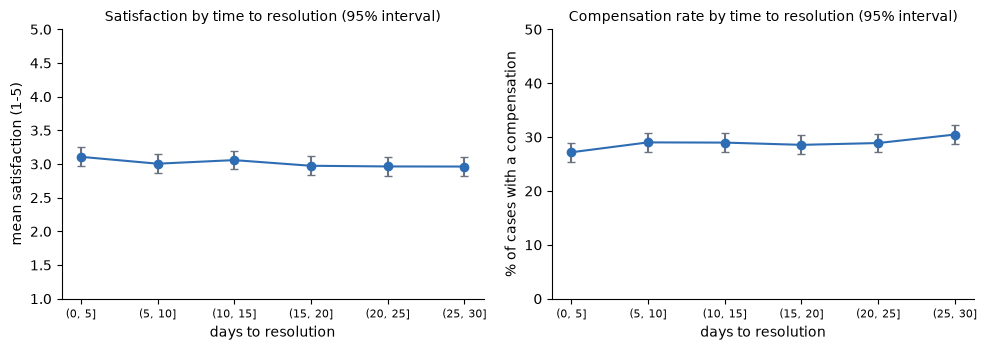

In [13]:
rated_resolved = rated.dropna(subset=["resolution_days"]).copy()
rated_resolved["resolution_band"] = pd.cut(rated_resolved["resolution_days"], RESOLUTION_DAY_BINS)
rated_resolved["has_compensation"] = rated_resolved["compensation_granted"].notna()

satisfaction_by_time = rated_resolved.groupby("resolution_band", observed=True)["resolution_satisfaction"].agg(
    ratings="size", mean="mean", std="std"
)
satisfaction_by_time = add_interval(satisfaction_by_time, "mean", "std", "ratings")
display(satisfaction_by_time)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
positions = range(len(satisfaction_by_time))
axes[0].errorbar(list(positions), satisfaction_by_time["mean"], yerr=satisfaction_by_time["mean_ci"], fmt="o-",
                 color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[0].set_ylim(1, 5)
axes[0].set_ylabel("mean satisfaction (1-5)")
axes[0].set_title("Satisfaction by time to resolution (95% interval)", fontsize=10)
axes[1].errorbar(list(positions), compensation_by_time["share_with_compensation"], yerr=compensation_by_time["share_ci_pp"],
                 fmt="o-", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
axes[1].set_ylim(0, 50)
axes[1].set_ylabel("% of cases with a compensation")
axes[1].set_title("Compensation rate by time to resolution (95% interval)", fontsize=10)
for axis in axes:
    axis.set_xticks(list(positions))
    axis.set_xticklabels([str(interval) for interval in satisfaction_by_time.index], fontsize=8)
    axis.set_xlabel("days to resolution")
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
def minimum_detectable_difference(values_a: pd.Series, values_b: pd.Series) -> float:
    """Computes the 95% half-width of a difference between two group means.

    Exists to state how large a satisfaction gap this sample could have revealed.

    Args:
        values_a: Ratings of the first group.
        values_b: Ratings of the second group.

    Returns:
        float: half-width of the 95% interval of the difference (rating points).
    """
    return 1.96 * (values_a.var() / len(values_a) + values_b.var() / len(values_b)) ** 0.5


comparisons = {
    "compensation granted vs not": (rated_resolved["has_compensation"], "resolution_satisfaction"),
    "SLA breached vs not": (rated_resolved["sla_breached"], "resolution_satisfaction"),
    "resolved in <= 15 days vs > 15 days": (rated_resolved["resolution_days"] <= 15, "resolution_satisfaction"),
}
rows = []
for name, (flag, column) in comparisons.items():
    yes, no = rated_resolved.loc[flag, column], rated_resolved.loc[~flag, column]
    rows.append({
        "comparison": name, "n_yes": len(yes), "n_no": len(no),
        "mean_yes": yes.mean(), "mean_no": no.mean(),
        "difference": yes.mean() - no.mean(),
        "95%_half_width": minimum_detectable_difference(yes, no),
    })
display(pd.DataFrame(rows).set_index("comparison"))
display(pd.Series({
    "Spearman: days to resolution vs satisfaction": rated_resolved["resolution_days"].rank().corr(rated_resolved["resolution_satisfaction"].rank()),
    "Spearman: compensation amount vs satisfaction (grants only)":
        rated_resolved.dropna(subset=["compensation_granted"])[["compensation_granted", "resolution_satisfaction"]].corr(method="spearman").iloc[0, 1],
}, name="value").to_frame())
for column in ["priority", "category", "reception_channel"]:
    display(add_interval(rated_resolved.groupby(column)["resolution_satisfaction"].agg(ratings="size", mean="mean", std="std"), "mean", "std", "ratings"))

,n_yes,n_no,mean_yes,mean_no,difference,95%_half_width
comparison,,,,,,
compensation granted vs not,690,1684,3.00,3.02,-0.02,0.13
SLA breached vs not,500,1874,2.99,3.02,-0.03,0.14
resolved in <= 15 days vs > 15 days,1198,1176,3.06,2.97,0.09,0.11


,value
Spearman: days to resolution vs satisfaction,-0.03
Spearman: compensation amount vs satisfaction (grants only),0.05


,ratings,mean,std,mean_ci
priority,,,,
Critical,108,3.19,1.43,0.27
High,379,2.90,1.44,0.15
Low,748,2.97,1.42,0.10
Medium,1139,3.06,1.42,0.08


,ratings,mean,std,mean_ci
category,,,,
Branch,494,3.03,1.44,0.13
Fees,443,2.96,1.40,0.13
Service,459,2.95,1.45,0.13
Technical,480,3.02,1.41,0.13
Transactions,498,3.09,1.42,0.13


,ratings,mean,std,mean_ci
reception_channel,,,,
App,234,2.95,1.36,0.17
Branch,93,2.68,1.50,0.31
Call Center,1185,3.04,1.43,0.08
Email,486,2.98,1.43,0.13
Regulator,29,2.93,1.49,0.54
Web,347,3.09,1.41,0.15


**Satisfaction is not related to time to resolution, compensation, or SLA breach.** The mean drifts from 3.11 (0-5 days) to 2.96 (25-30 days), a gap of 0.15 that is within the +/-0.14 noise of each band, and
the correlation is about -0.03.
Customers who received a compensation are as satisfied as those who did not (differences are well
inside the sample's resolution of roughly +/-0.13 points). Slower resolution and compensation are not
visibly punished or rewarded in the ratings. The sample (about 2,400 rated cases) is large enough to
have shown a gap of a quarter of a point, so this is evidence of no relationship, not just lack of data.

## 7. Agents and repeat complainers

In [15]:
cases_per_agent = complaints.groupby("assigned_agent_id").size()
per_agent = resolved.groupby("assigned_agent_id")["resolution_days"].agg(["size", "mean"])
per_agent = per_agent[per_agent["size"] >= 10]
population_std = resolved["resolution_days"].std()
display(pd.Series({
    "agents": len(cases_per_agent),
    "cases per agent, min / median / max": f"{cases_per_agent.min()} / {cases_per_agent.median():.0f} / {cases_per_agent.max()}",
    "agents with >= 10 resolved cases": len(per_agent),
    "std of agents' mean days to resolution (observed)": per_agent["mean"].std(),
    "std expected if agents were identical (pure sampling noise)": ((population_std ** 2 / per_agent["size"]).mean()) ** 0.5,
}, name="value").to_frame())

complaints_per_customer = complaints.groupby("customer_id").size().rename("complaints_of_customer")
flagged = complaints.merge(complaints_per_customer, on="customer_id")
display(flagged.groupby("is_repeat_complainer")["complaints_of_customer"].agg(["size", "mean"]))
display(complaints_per_customer.value_counts().sort_index().to_frame("customers"))

,value
agents,1200
"cases per agent, min / median / max",18 / 36 / 61
agents with >= 10 resolved cases,940
std of agents' mean days to resolution (observed),2.44
std expected if agents were identical (pure sampling noise),2.42


,size,mean
is_repeat_complainer,,
False,57009,1.45
True,10086,1.44


,customers
complaints_of_customer,
1,42966
2,9599
3,1408
4,155
5,15
6,2


**Agents.** The spread of average resolution time across agents (2.44 days) equals what pure chance would
produce with identical agents (2.42), so there is no evidence of faster or slower agents. Workload is
balanced (18-61 cases each). That leaves little "best agent behaviour" to learn from.

**Repeat complainers.** The `is_repeat_complainer` flag (15% of complaints) does not correspond to actual
repeat behaviour: flagged and unflagged customers have the same average number of complaints (1.44 vs 1.45). Real
repetition exists (about 20% of complaining customers have two or more complaints) but the flag does not
capture it.

## 8. Joins with customers and products

In [16]:
customers = pd.read_csv(DATA_DIRECTORY / "customers.csv", usecols=["customer_id", "segment", "country", "customer_status"])
products = pd.read_csv(DATA_DIRECTORY / "products.csv", usecols=["product_id", "customer_id", "product_type", "opening_date"],
                       parse_dates=["opening_date"])

customers["complaints"] = customers["customer_id"].map(complaints_per_customer).fillna(0)
display(pd.Series({
    "complaint customer_ids present in customers.csv": complaints["customer_id"].isin(customers["customer_id"]).mean() * 100,
    "customers with at least one complaint (%)": (customers["complaints"] > 0).mean() * 100,
}, name="value").to_frame())
for column in ["segment", "country", "customer_status"]:
    display(customers.groupby(column)["complaints"].agg(share_with_complaint=lambda s: (s > 0).mean() * 100, mean_complaints="mean"))

with_product = complaints.dropna(subset=["affected_product_id"]).merge(
    products, left_on="affected_product_id", right_on="product_id", how="left", suffixes=("", "_product_owner")
)
display(pd.Series({
    "complaints naming an affected product": len(with_product),
    "  product found in products.csv (%)": with_product["product_id"].notna().mean() * 100,
    "  product belongs to the complaining customer (%)": (with_product["customer_id"] == with_product["customer_id_product_owner"]).mean() * 100,
    "  complaint created before the product's opening_date (%)":
        (with_product["creation_date"].dt.normalize() < with_product["opening_date"]).mean() * 100,
}, name="value").to_frame())
display(pd.crosstab(with_product["category"], with_product["product_type"], normalize="index").mul(100))

,value
complaint customer_ids present in customers.csv,100.00
customers with at least one complaint (%),36.10


,share_with_complaint,mean_complaints
segment,,
Basic,36.05,0.45
Plus,36.18,0.45
Premium,36.18,0.44
Student,36.03,0.45


,share_with_complaint,mean_complaints
country,,
Argentina,36.12,0.45
Colombia,36.20,0.45
México,36.02,0.45


,share_with_complaint,mean_complaints
customer_status,,
Active,36.23,0.45
Closed,33.23,0.41
Inactive,35.64,0.44
Suspended,35.72,0.44


,value
complaints naming an affected product,"44,570.00"
product found in products.csv (%),100.00
product belongs to the complaining customer (%),0.00
complaint created before the product's opening_date (%),18.74


product_type,Cuenta Ahorro,Cuenta Corriente,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito
category,,,,,,,,
Branch,30.87,24.16,1.45,3.02,4.59,0.47,25.52,9.92
Fees,30.46,24.74,1.55,3.06,5.10,0.44,24.75,9.90
Service,30.42,25.29,1.49,2.86,4.83,0.52,25.08,9.51
Technical,30.34,25.20,1.19,2.73,5.02,0.51,24.86,10.15
Transactions,29.56,26.51,1.41,3.18,4.79,0.50,23.93,10.12


Customer keys join cleanly (100%), but **the affected product never belongs to the customer who
complains** (0% ownership match), and ~19% of complaints predate the product's opening. Complaint
categories are spread over product types exactly like the product base (a "Fees" complaint is as likely
to name a savings account as a credit card). The share of customers who complain is the same (~36%) across segment and country (slightly lower, 33%, for customers whose status is `Closed`). In this data, complaints are not connected to the customer or product they claim to concern.

### Compensation and customer status (a rough retention proxy)

`customers.csv` has one `customer_status` per customer at an unknown date, so this is cross-sectional
and cannot show retention over time. It only checks whether customers who were compensated look
different today.

In [17]:
compensated_customers = (
    eligible.assign(has_compensation=eligible["compensation_granted"].notna())
    .groupby("customer_id")["has_compensation"].any().rename("was_compensated").reset_index()
    .merge(customers[["customer_id", "customer_status"]], on="customer_id")
)
status_by_compensation = pd.crosstab(compensated_customers["was_compensated"], compensated_customers["customer_status"])
display(status_by_compensation)
not_active = (compensated_customers["customer_status"] != "Active")
display(not_active.groupby(compensated_customers["was_compensated"]).agg(
    customers="size", not_active_pct=lambda s: s.mean() * 100,
).assign(ci_half_width_pct=lambda t: 196 * (t["not_active_pct"] / 100 * (1 - t["not_active_pct"] / 100) / t["customers"]) ** 0.5))

customer_status,Active,Closed,Inactive,Suspended
was_compensated,,,,
False,9183,182,1057,286
True,3929,73,433,143


,customers,not_active_pct,ci_half_width_pct
was_compensated,,,
False,10708,14.24,0.66
True,4578,14.18,1.01


## 9. Sizing the agentic-workflow opportunity

Baseline that a workflow would try to move, straight from the data:

In [18]:
baseline = pd.Series({
    "complaints in 3 years": len(complaints),
    "complaints per full month (median)": monthly.iloc[1:-1].median(),
    "active backlog (Open + In Process + Escalated)": len(backlog),
    "  of which Open with no agent": (backlog["status"] == "Open").sum(),
    "  of which Escalated with no first response": (backlog["status"] == "Escalated").sum(),
    "median hours to assignment": hours_to_assignment.median(),
    "median hours to first response": hours_to_first_response.median(),
    "median days to resolution (resolved)": resolved["resolution_days"].median(),
    "share of resolution time before first response, %":
        (paired["hours_to_first_response"] / 24).mean() / paired["resolution_days"].mean() * 100,
    "compensation granted, total raw units": granted["compensation_granted"].sum(),
    "share of Resolved + Closed with a compensation, %": len(granted) / len(eligible) * 100,
    "customers rated (of all complaints), %": len(rated) / len(complaints) * 100,
    "mean satisfaction (1-5)": rated["resolution_satisfaction"].mean(),
}, name="baseline")
display(baseline.to_frame())

,baseline
complaints in 3 years,"67,095.00"
complaints per full month (median),"1,874.00"
active backlog (Open + In Process + Escalated),"50,269.00"
of which Open with no agent,"20,125.00"
of which Escalated with no first response,"3,321.00"
median hours to assignment,12.00
median hours to first response,38.00
median days to resolution (resolved),16.00
"share of resolution time before first response, %",10.00
"compensation granted, total raw units","1,174,809.70"


## 10. Conclusions

**Short answer.** On its face the complaint process has a large, slow, undifferentiated queue that an
agentic workflow could target. But this dataset **cannot confirm that the queue is real, cannot size the
benefit, and shows no relationship between speed, compensation and satisfaction**. The opportunity is
plausible; it is not demonstrated.

### A. Is there an opportunity for an agentic workflow?

**What the data says at face value (baseline):**

- 67,095 complaints in three years, ~1,870 per full month, flat over time.
- **50,269 (74.9%) are in an active status** (Open, In Process, Escalated); 33,413 of them are older
  than a year. 20,125 are `Open` with **no agent assigned**, and 3,321 are `Escalated` with **no first
  response**. 23,115 complaints have never had an agent.
- For cases that were resolved: median **12 h to assignment, 38 h to first response, 16 days to resolution**.
  Only ~10% of that time is spent waiting for the first response.
- The process does not differentiate: **Critical cases take as long as Low ones** (15.5 vs 15.7 days), a
  `Regulator` complaint takes as long as any other, and resolution time is unrelated to category, channel or case type.
- Agents are interchangeable: the spread of average resolution time across agents (2.44 days) equals what
  chance alone produces (2.42). Workload is balanced (18-61 cases each).

**Why this cannot yet be treated as a demonstrated opportunity:**

- The share of complaints in a terminal status is ~25% **at every age** (25% for last month's complaints
  and for 2023 ones). In a real queue, older complaints are far more likely to be resolved. The statuses
  look randomly assigned, so the 75% "backlog" may not be real.
- `sla_breached` is ~20% whatever the priority, resolution time or status, so it is not derived from the
  timestamps and cannot measure SLA performance.
- Stage durations are uniform (assignment 1-24 h, first response 3-72 h, resolution 1-30 days).
- There is **no free text** (5 description and 5 resolution sentences) and `origin_interaction_id` is empty:
  an agent's understanding of complaints or quality of answers cannot be evaluated or compared with the
  current process on this data.
- The complaint is not connected to its customer or product: the affected product never belongs to the
  complaining customer (0% match), 18.7% of complaints predate the product's opening, categories are
  spread over product types like the product base, and complaint rates are the same (~36%) across
  segments and countries.
- There is no measure of **effort or cost** (agent time, touches, reopenings), so savings cannot be sized.

### B. Compensation granted

- **4,641 grants**: 6.9% of all complaints, **28.8% of Resolved + Closed** cases. Total **1,174,810 raw
  units**, mean 253 (10-500) per grant. There is **no currency** on compensation (only on the claimed
  amount), so it cannot be converted or compared with claims in a common unit.
- It looks arbitrary: the grant rate is 27-31% for every resolution text (including the one that says
  "compensation granted"), category, priority and case type. The amount does not follow the claim
  (median grant is 10% of the claimed amount, Spearman 0.03, and 62 grants exceed the claim). Only the
  small `Regulator` group stands out (36.5% on 181 cases, barely beyond noise).
- **Not related to time to resolution**: 27-30% granted in every resolution-time band, mean amount 247-260;
  slower cases are not compensated more.
- Compensated customers are not less likely to be inactive today (14.2% not Active, vs 14.2% of
  non-compensated), a cross-sectional check only.

### C. Satisfaction

- Only **2,484 ratings (3.7% of complaints)**; only `Closed` cases are rated. Mean **3.02 out of 5**, and each
  score 1-5 holds ~20% of the ratings (uniform).
- **No relationship with time to resolution**: mean 3.11 in the fastest band (0-5 days) to 2.96 in the slowest
  (25-30 days), a 0.15 drift inside the +/-0.14 noise of each band; correlation -0.03.
- **No relationship with compensation** (3.00 with vs 3.02 without, +/-0.13) or **SLA breach** (2.99 vs 3.02, +/-0.14);
  cases resolved in <= 15 days are rated 3.06 vs 2.97 (+0.09, +/-0.11). The sample can resolve differences of about
  0.13 points, so a quarter-point effect would have shown. This is evidence of no relationship, not lack of data.

### D. Compensation, satisfaction and time-to-resolution together

Nothing connects them in this data. Faster resolution does not raise satisfaction, compensation does not
raise satisfaction, and slower cases are not compensated more. We therefore **cannot claim that speeding
up resolution would improve satisfaction, or that compensation buys goodwill**. The
~1.17 M of compensation has no measurable association with any observed outcome.

### What would be needed to size the opportunity

1. **Confirmation from the system owners** that the ~75% active backlog and its age profile are real. If they are, that alone is the opportunity.
2. **A status-history (event) log**, to measure time in each state and re-openings.
3. **Effort and cost per case** (agent time, touches) to convert speed-ups into money.
4. **Real complaint text and resolution notes**, and the linked interactions (`origin_interaction_id`), to evaluate an agent on real content.
5. **Satisfaction collected for all resolved cases**, with a known response process, and **customer outcomes** (retention, churn, later complaints) after resolution.
6. **Compensation currency and policy**, and an amount-due/claim basis.

### Suggested next steps

- Validate the backlog with the owners (this decides everything).
- Instrument the process (time-in-state, effort, CSAT for all resolved cases) for 1-2 months.
- Then pilot an agent-assisted triage/first-response step on **new** complaints against a control group,
  measuring time to first response, time to resolution and satisfaction. That produces the causal evidence
  this historical data cannot.